In [27]:
from google.colab import files
files.upload()  # kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (2).json


In [28]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content
!unzip -q /content/brain-tumor-mri-dataset.zip -d /content/BrainTumorData

# بررسی ساختار پوشه‌ها
!ls /content/BrainTumorData
!ls /content/BrainTumorData/Training

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 263MB/s]

brain_tumor_dataset  no  Testing  Training  yes
glioma	      meningioma	no_tumor  pituitary
glioma_tumor  meningioma_tumor	notumor   pituitary_tumor


In [29]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

In [30]:
IMG_SIZE = 128
TRAIN_DIR = "/content/BrainTumorData/Training"
TEST_DIR = "/content/BrainTumorData/Testing"

categories = ["glioma", "meningioma", "notumor", "pituitary"]

def load_data(data_dir):
    data = []
    labels = []
    for category in categories:
        folder_path = os.path.join(data_dir, category)
        label = categories.index(category)
        for img_name in os.listdir(folder_path):
            try:
                img_path = os.path.join(folder_path, img_name)
                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                data.append(img)
                labels.append(label)
            except Exception as e:
                print(f"خطا در خواندن {img_name}: {e}")
    return np.array(data), np.array(labels)

print("در حال بارگذاری داده آموزش...")
X_train, y_train = load_data(TRAIN_DIR)

print("در حال بارگذاری داده تست...")
X_test, y_test = load_data(TEST_DIR)

# نرمال‌سازی
X_train = X_train / 255.0
X_test = X_test / 255.0

# تبدیل لیبل‌ها به one-hot encoding (چون ۴ کلاسه هستیم)
y_train_cat = to_categorical(y_train, num_classes=4)
y_test_cat = to_categorical(y_test, num_classes=4)

print(f"\nتعداد داده آموزش: {len(X_train)}")
print(f"تعداد داده تست: {len(X_test)}")
print(f"شکل داده: {X_train.shape}")

در حال بارگذاری داده آموزش...
در حال بارگذاری داده تست...

تعداد داده آموزش: 5600
تعداد داده تست: 1600
شکل داده: (5600, 128, 128, 3)


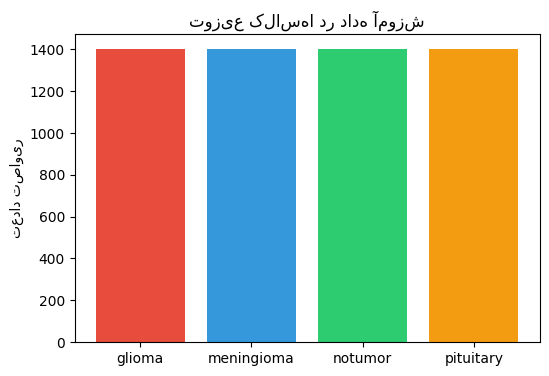

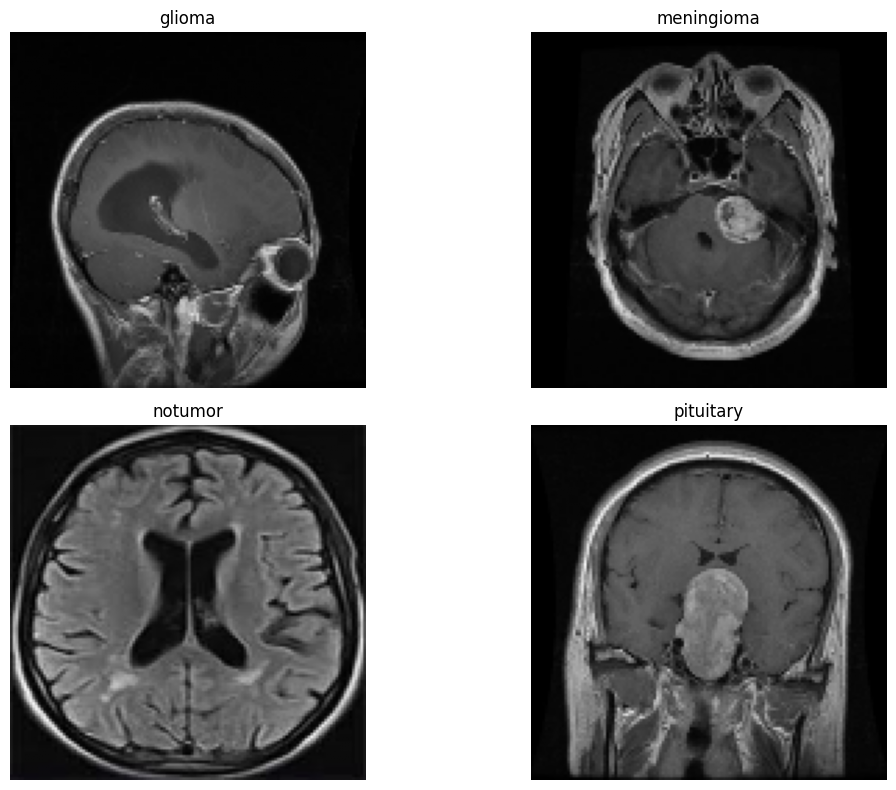

In [31]:
# توزیع کلاس‌ها
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(6, 4))
plt.bar([categories[i] for i in unique], counts, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
plt.title("توزیع کلاس‌ها در داده آموزش")
plt.ylabel("تعداد تصاویر")
plt.show()

# نمایش نمونه از هر کلاس
plt.figure(figsize=(12, 8))
for i, category in enumerate(categories):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 2, i + 1)
    plt.imshow(X_train[idx])
    plt.title(category)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [32]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # ۴ خروجی برای ۴ کلاس
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # چندکلاسه -> categorical
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,916 (10.49 MB)

 Trainable params: 2,749,956 (10.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [33]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)

In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=3)
]

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_test, y_test_cat),
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 150ms/step - accuracy: 0.8554 - loss: 0.3916 - val_accuracy: 0.7550 - val_loss: 1.1491 - learning_rate: 5.0000e-04
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.8636 - loss: 0.3674 - val_accuracy: 0.6531 - val_loss: 1.8330 - learning_rate: 5.0000e-04
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.8623 - loss: 0.3663 - val_accuracy: 0.6494 - val_loss: 1.9217 - learning_rate: 5.0000e-04
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step - accuracy: 0.8873 - loss: 0.3002 - val_accuracy: 0.8087 - val_loss: 0.8556 - learning_rate: 5.0000e-04
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - accuracy: 0.8855 - loss: 0.3001 - val_accuracy: 0.6288 - val_loss: 1.6010 - learning_rate: 5.0000e-04
Epoch 6/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 143ms/step - accuracy: 0.8986 - loss: 0.2757 - val_accuracy: 0.8325 - val_loss: 0.8698 - learning_rate: 5.0000e-04
Epoch 7/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 24s 13

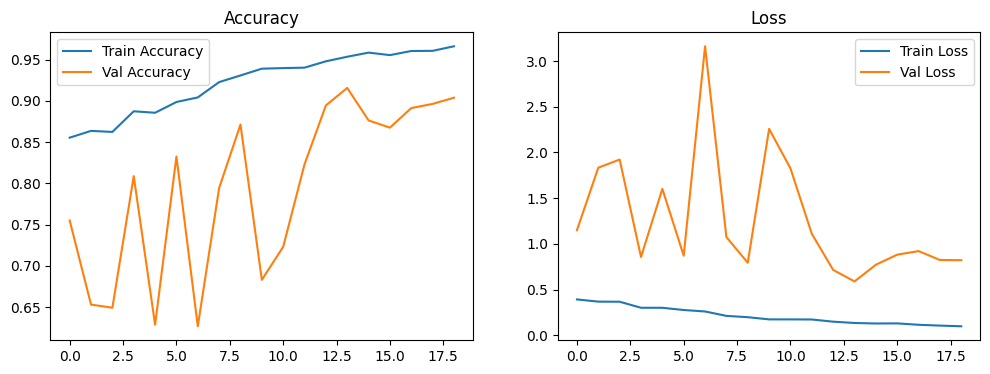

In [39]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9156 - loss: 0.5883
دقت روی داده تست: 91.56%
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

گزارش کامل:
              precision    recall  f1-score   support

      glioma       0.97      0.79      0.87       400
  meningioma       0.92      0.88      0.90       400
     notumor       0.86      1.00      0.92       400
   pituitary       0.94      0.99      0.96       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.91      1600
weighted avg       0.92      0.92      0.91      1600



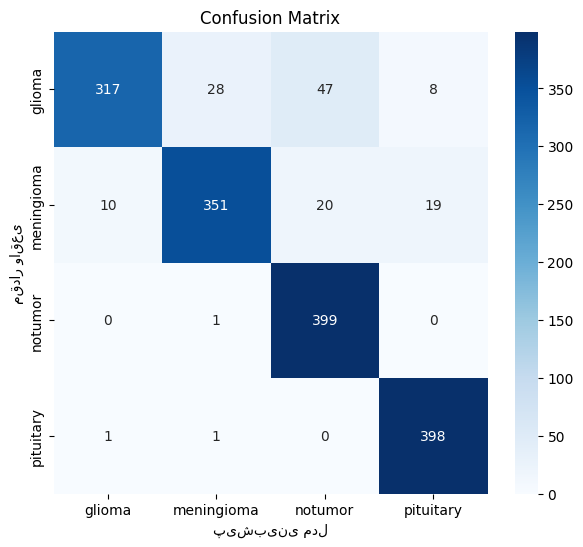

In [40]:
loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f"دقت روی داده تست: {accuracy * 100:.2f}%")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nگزارش کامل:")
print(classification_report(y_test, y_pred, target_names=categories))

# Confusion Matrix به صورت گرافیکی
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel("پیش‌بینی مدل")
plt.ylabel("مقدار واقعی")
plt.title("Confusion Matrix")
plt.show()

In [41]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_input = np.expand_dims(img_resized / 255.0, axis=0)

    pred = model.predict(img_input)[0]
    predicted_class = categories[np.argmax(pred)]
    confidence = np.max(pred) * 100

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"پیش‌بینی: {predicted_class} ({confidence:.1f}%)")
    plt.axis("off")
    plt.show()

    print("احتمال هر کلاس:")
    for cat, prob in zip(categories, pred):
        print(f"  {cat}: {prob*100:.2f}%")

